### Concepts shown in this demo notebook:

* Measuring the structure of PCTrees with persistent homology measures.
* Deomonstrating the effect of `sifting_effect_size` on PCTree structure.

**Things to try:**
* Evaluate the compression performance of `tree_wide` and `tree_tall` and see how the differ. 

In [ ]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt

from pctree.training import PCTreeTrainerOptions, PCTreeTrainer
from pctree.persistent_homology import WidthFiltration, HeightFiltration
from pctree.display import plot, get_pct_display_info

import warnings
warnings.filterwarnings('ignore')

In [2]:
mnist_X = np.load("../data/mnist_train.npy").astype(np.float32)
X_mean = mnist_X.mean(axis=0)
mnist_X -= X_mean

In [3]:
trainer = PCTreeTrainer(PCTreeTrainerOptions(50, max_children=3, max_width=50, sifting_effect_size=0.3))
trainer.fit_partition(mnist_X, verbose=1)
tree_wide = trainer.fit_em(mnist_X, X_topdown=mnist_X, verbose=0)

trainer = PCTreeTrainer(PCTreeTrainerOptions(50, max_children=3, max_width=50, sifting_effect_size=0.7))
trainer.fit_partition(mnist_X, verbose=1)
tree_tall = trainer.fit_em(mnist_X, X_topdown=mnist_X, verbose=0)

Performing top-down partitioning to create initial PCT. 
Log Key: `-` is a node expanded by adding one additional child. `<` is a node expanded by spliting into two nodes. 
<<---<<<-<<<-----<<<<----<-<-<<-<<<--------------
Performing top-down partitioning to create initial PCT. 
Log Key: `-` is a node expanded by adding one additional child. `<` is a node expanded by spliting into two nodes. 
---<--<----<----<---<--<-<<<---------<-<-<<------


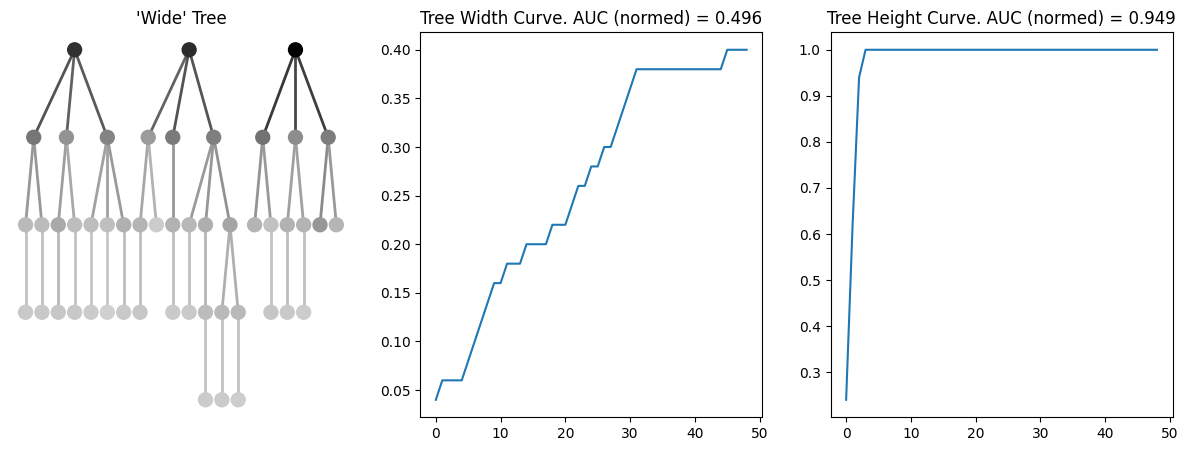

In [4]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.set_axis_off()
plot(get_pct_display_info(tree_wide), ax1)
width_curve_norm, width_curve_sum_norm = WidthFiltration().measure(tree_wide, standardize=True)
height_curve_norm, height_curve_sum_norm = HeightFiltration().measure(tree_wide, standardize=True)
ax1.set_title("'Wide' Tree")
ax2.set_title(f"Tree Width Curve. AUC (normed) = {round(width_curve_sum_norm, 3)}")
ax3.set_title(f"Tree Height Curve. AUC (normed) = {round(height_curve_sum_norm, 3)}")
ax2.plot(width_curve_norm)
ax3.plot(height_curve_norm)

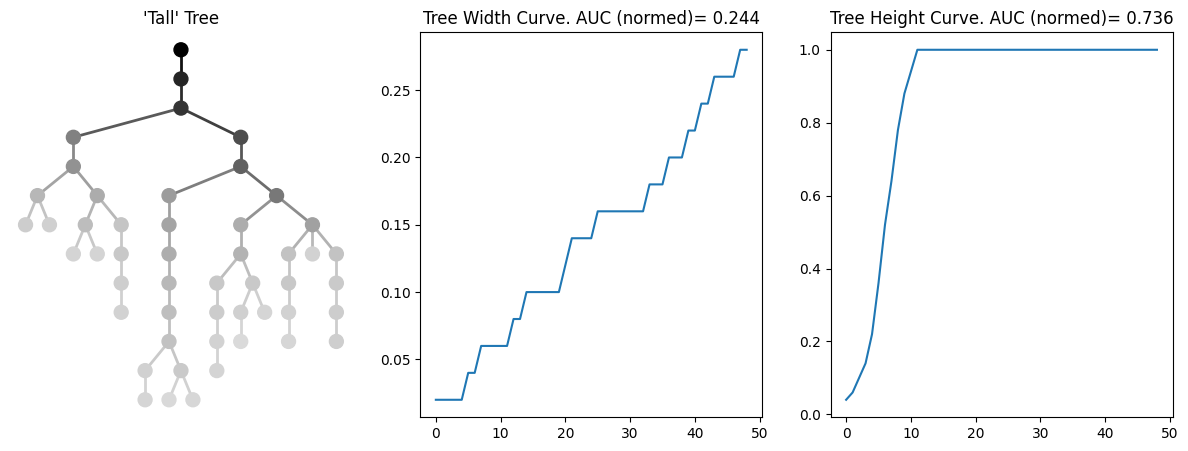

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.set_axis_off()
plot(get_pct_display_info(tree_tall), ax1)
width_curve_norm, width_curve_sum_norm = WidthFiltration().measure(tree_tall, standardize=True)
height_curve_norm, height_curve_sum_norm = HeightFiltration().measure(tree_tall, standardize=True)
ax1.set_title("'Tall' Tree")
ax2.set_title(f"Tree Width Curve. AUC (normed)= {round(width_curve_sum_norm, 3)}")
ax3.set_title(f"Tree Height Curve. AUC (normed)= {round(height_curve_sum_norm, 3)}")
ax2.plot(width_curve_norm)
ax3.plot(height_curve_norm)